In [1]:
import numpy as np

from model_ranking.results import load_transfer_metric_results
from model_ranking.plots import plot_performance_vs_transfer_metric

from model_ranking.correlation import calculate_correlation_statistics
from model_ranking.results import (
    transfer_results_to_arrays,
)

INFO: P [MainThread] 2025-08-14 09:51:02,989 plantseg - Logger configured at initialisation. PlantSeg logger name: plantseg


In [2]:
path = "/scratch/talks/sampled_features/semantic_segmentation/mitochondria/transfer_metric_results/mitochondria_LogME.json"

results = load_transfer_metric_results(path)
scores = results["transfer_scores"]
performance_scores = results["performance_scores"]
correlation_scores = results["correlation_scores"]

Loaded Transfer metric results from: /scratch/talks/sampled_features/semantic_segmentation/mitochondria/transfer_metric_results/mitochondria_LogME.json
Experiment: mitochondria_LogME
Targets: 4 (EPFL, Hmito, Rmito, VNC)
Source models: 15
Total transfers: 57


Target: EPFL


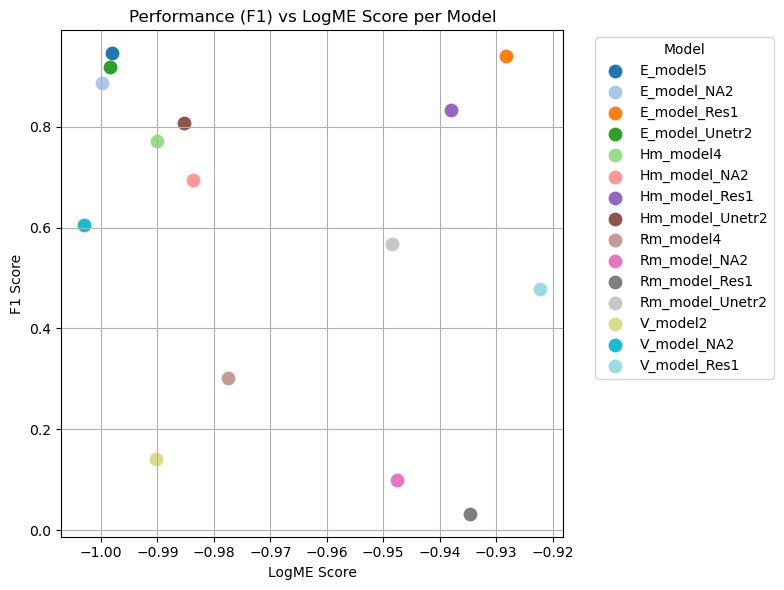

Target: Hmito


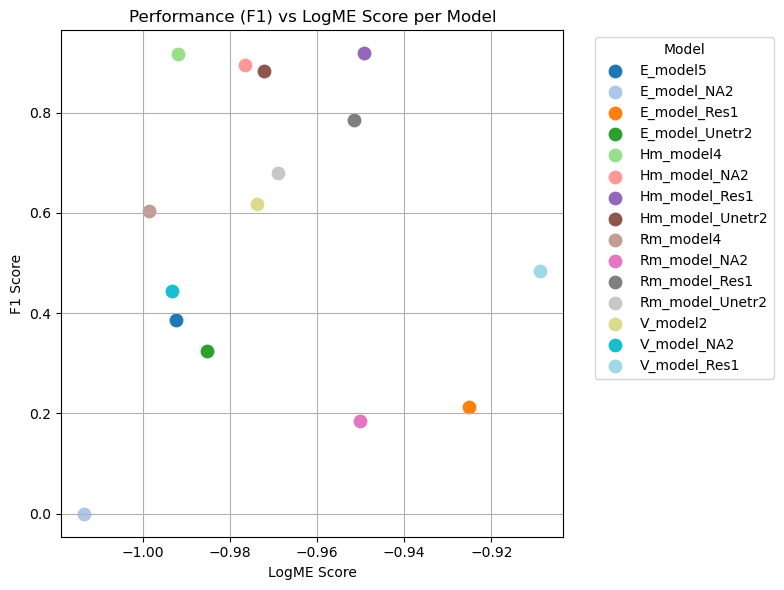

Target: Rmito


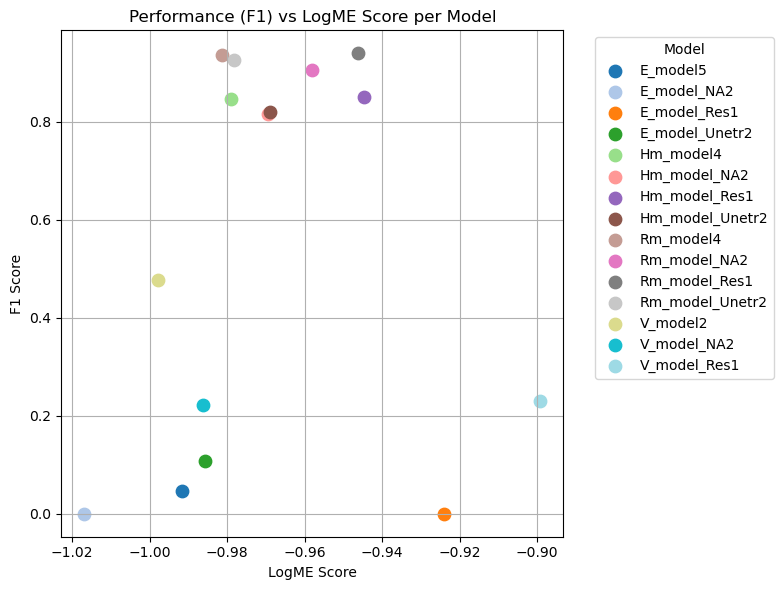

Target: VNC


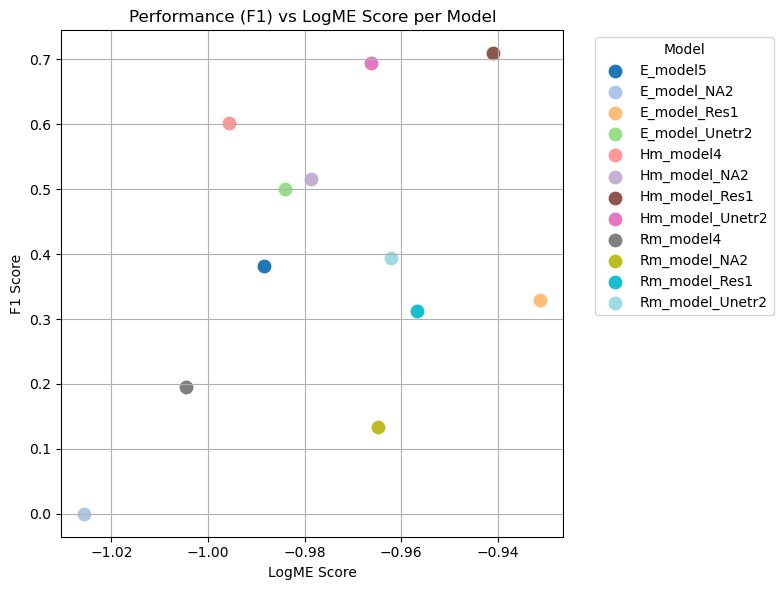

In [3]:
for target, scores_per_model in scores.items():
    print(f"Target: {target}")
    plot_performance_vs_transfer_metric(performance_scores[target], scores_per_model, metric_name="LogME")

In [4]:
import pandas as pd
idx = 0
per_target_KT = np.array(correlation_scores["KT"])
per_target_SP = np.array(correlation_scores["SP"])
per_target_PE = np.array(correlation_scores["PE"])
df = pd.DataFrame(
    {
        "kt": per_target_KT[:, idx, 0], 
        "kt pval": per_target_KT[:, idx, 1], 
        "s rho": per_target_SP[:, idx, 0], 
        "s rho pval": per_target_SP[:, idx, 1], 
        "pr": per_target_PE[:, idx, 0], 
        "pr pval": per_target_PE[:, idx, 1]
    },
)
df["targets"] = results["metadata"]["targets"]
df = df.set_index("targets")
df.index = pd.MultiIndex.from_product([["Mito"], df.index], names=["Task", "targets"])
# Round all float columns to 2 significant figures
df = df.map(lambda x: round(x, 2) if isinstance(x, float) else x)
print(df)

                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL    -0.30     0.27  -0.33        0.23 -0.24     0.23
     Hmito    0.05     0.85   0.17        0.56  0.10     0.61
     Rmito    0.09     0.75   0.32        0.24  0.25     0.22
     VNC      0.41     0.18   0.25        0.43  0.21     0.39
